# 70 - Looking Inside a CNN: Feature Maps

**Section:** CNNs | **Prereqs:** `CNNs/CNN_CIFAR_100.ipynb` | **Next:** `CNNs/CodeChallenge_Softcode_Internal_Parameters.ipynb`

CNNs are far less opaque than they are made out to be. Every intermediate
activation is an image, and looking at those images tells you what the network is
responding to.

**The technique:** have `forward()` collect its intermediate tensors and return
them alongside the prediction, gated by a flag so normal training is unaffected.

```python
def forward(self, x, get_maps=False):
    maps = []
    x = self.pool1(self.relu1(self.conv1(x))); maps.append(x)
    ...
    return (out, maps) if get_maps else out
```

(The general-purpose alternative is a forward hook - `layer.register_forward_hook`
- which needs no change to the model at all.)

**What you will see, layer by layer**
- **Conv1** - 32 versions of the input, each emphasising something different:
  edges at various orientations, blobs, inverted contrast. Recognisably the input.
- **Conv2** - smaller and more abstract; combinations of the first layer's features.
- **Conv3** - tiny and unreadable to a human. These are the features the
  classifier actually uses.
- **After global average pooling** - a single number per channel.

**The general pattern:** early layers are generic (edges, colours - similar across
every trained CNN, which is why transfer learning works), late layers are specific
to the task.

**The task here** is classifying Gaussian blobs by width, which is deliberately
position-independent - so the model must learn a *shape* feature rather than
memorising locations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.model_selection import train_test_split

In [2]:
# The synthetic dataset for this notebook: 2-D Gaussian blobs at random centres,
# with one of two widths (sigma = 1.8 or 2.4), plus noise.
# The label is which sigma was used - i.e. the task is 'is this blob wide or
# narrow', which is position-independent by construction. Perfect for a CNN, and
# nearly impossible for an FNN, which would have to learn it separately at every
# location.
image_size = 91
n_perClass = 1000

x = np.linspace(-4,4,image_size)

X,Y = np.meshgrid(x,x)

sigma = [1.8,2.4]


image = np.zeros((2*n_perClass,1, image_size, image_size), dtype=float)
labels = np.zeros(2*n_perClass)

for i in range(2*n_perClass):

  C = 2*np.random.randn(2) # Creating Random centers

  X_hat = X - C[0]
  Y_hat = Y - C[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i%2]))

  noise = np.random.randn(*(G.shape))/5

  #Adding noise
  G += noise

  image[i] = G.reshape(1, image_size,image_size)
  labels[i] = i%2

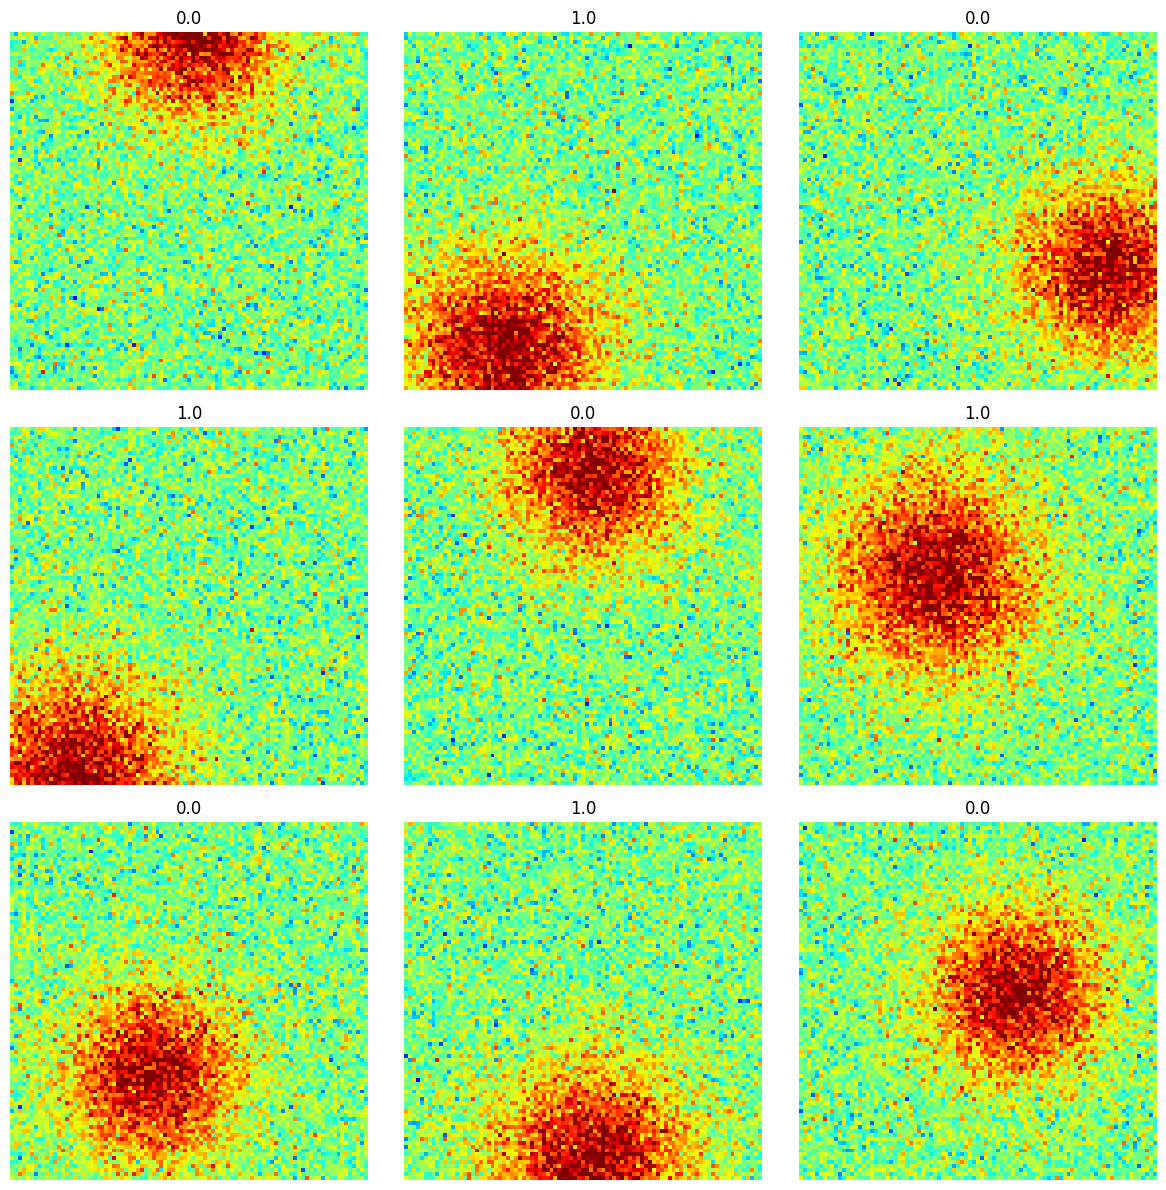

In [3]:
# Samples from both classes. The width difference is subtle by eye, which makes
# the model's accuracy more interesting.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(2*n_perClass, len(ax))):
  ax[i].imshow(np.squeeze(image[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].set_title(str(labels[i].item()));
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Standard split and loaders. Note the data is already shaped (N,1,H,W).
# Data Loader

device = ('cuda' if torch.cuda.is_available() else 'cpu')
train_data, test_data, train_label, test_label = train_test_split(image, labels, test_size=0.10)

train_tensor = torch.tensor(train_data, dtype=torch.float , device=device)
train_label = torch.tensor(train_label, dtype=torch.long, device=device)

test_tensor = torch.tensor(test_data, dtype=torch.float , device=device)
test_label = torch.tensor(test_label, dtype=torch.long, device=device)

train_dataset = TensorDataset(train_tensor, train_label)
test_dataset = TensorDataset(test_tensor , test_label)

bs = 8
train_loader = DataLoader(train_dataset ,batch_size=bs , drop_last=True, shuffle=True)
test_loder = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [60]:
# The model, with each conv/relu/pool stage as a separate attribute so it can be
# stepped through, and a get_map_bool flag that makes forward() also return the
# list of intermediate activations.
# Keeping the flag off by default means training code is untouched.
# (A forward hook - layer.register_forward_hook - does the same without editing
# the model, and is the general-purpose tool for this.)
class BlurModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,32,stride=2,padding=1,kernel_size=3)
    self.relu1 = nn.ReLU()
    self.pool1 = nn.MaxPool2d((2,2))

    self.conv2 = nn.Conv2d(32,64, stride=1, padding=1, kernel_size=3)
    self.relu2 = nn.ReLU()
    self.pool2 = nn.MaxPool2d((2,2))

    self.conv3 = nn.Conv2d(64,128,stride=1, padding=1, kernel_size=3)
    self.relu3 = nn.ReLU()
    self.pool3 = nn.MaxPool2d((2,2))

    self.adaptive_avg_pool = nn.AdaptiveAvgPool2d((1,1))

    self.fc1 = nn.Linear(128,64)
    self.out = nn.Linear(64,1)


  def forward(self,x,get_map_bool=False):

    feature_maps = []

    x = self.pool1(self.relu1(self.conv1(x)))
    feature_maps.append(x)
    x = self.pool2(self.relu2(self.conv2(x)))
    feature_maps.append(x)
    x = self.pool3(self.relu3(self.conv3(x)))
    feature_maps.append(x)
    x = self.adaptive_avg_pool(x)
    feature_maps.append(x)

    x = x.view(x.size(0), -1)

    x = F.relu(self.fc1(x))

    if get_map_bool:
      return self.out(x), feature_maps

    return self.out(x)

In [61]:
# torchsummary to confirm the shapes at each stage.
from torchsummary import summary

test_model = BlurModel()
test_model.to(device) # Move the model to the GPU
summary(test_model, input_size=(1,91,91))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 46, 46]             320
              ReLU-2           [-1, 32, 46, 46]               0
         MaxPool2d-3           [-1, 32, 23, 23]               0
            Conv2d-4           [-1, 64, 23, 23]          18,496
              ReLU-5           [-1, 64, 23, 23]               0
         MaxPool2d-6           [-1, 64, 11, 11]               0
            Conv2d-7          [-1, 128, 11, 11]          73,856
              ReLU-8          [-1, 128, 11, 11]               0
         MaxPool2d-9            [-1, 128, 5, 5]               0
AdaptiveAvgPool2d-10            [-1, 128, 1, 1]               0
           Linear-11                   [-1, 64]           8,256
           Linear-12                    [-1, 1]              65
Total params: 100,993
Trainable params: 100,993
Non-trainable params: 0
-------------------------------

In [62]:
# Training. BCEWithLogitsLoss for the binary task.
# The threshold is `yhat > 0`: the model emits a raw LOGIT, and sigmoid(0) = 0.5,
# so zero is the logit-space equivalent of a half probability.
def model_training():

  model = BlurModel().to(device)


  lossFunc = nn.BCEWithLogitsLoss()
  epochs = 50 # Increased epochs
  optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    )

  losses = []
  train_acc = []
  val_acc = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:
      x = x.to(device)
      y = y.to(device)
      yhat = model(x)


      loss = lossFunc(yhat, y.float().unsqueeze(1))
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


      acc = 100 * torch.mean( ((yhat > 0) == y.float().unsqueeze(1)).float().detach().cpu())
      batch_acc.append(acc)

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Now validation
    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loder))
      X = X.to(device)
      Y = Y.to(device)
      val_acc.append( 100 * torch.mean( ( (model(X) > 0) == Y.float().unsqueeze(1) ).float().detach().cpu() ) )


    if epoch % 10 == 0 or epoch == epochs-1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]:.4f} | Train Acc {train_acc[epoch]:.2f} | Val Acc : {val_acc[epoch]:.2f}')

  return model, losses, train_acc, val_acc

In [63]:
model, losses, train_acc, val_acc = model_training()

Epoch 0 | Loss : 0.6777 | Train Acc 54.50 | Val Acc : 61.00
Epoch 10 | Loss : 0.2307 | Train Acc 88.00 | Val Acc : 88.00
Epoch 20 | Loss : 0.0841 | Train Acc 96.39 | Val Acc : 94.50
Epoch 30 | Loss : 0.1045 | Train Acc 95.28 | Val Acc : 98.00
Epoch 40 | Loss : 0.0877 | Train Acc 96.50 | Val Acc : 93.50
Epoch 49 | Loss : 0.0265 | Train Acc 98.94 | Val Acc : 93.50


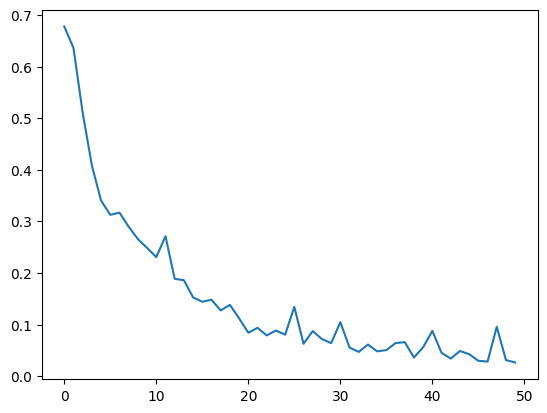

In [64]:
# Loss curve.
plt.plot(losses);

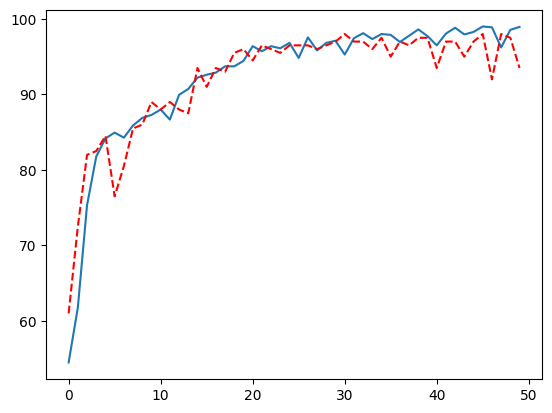

In [65]:
# Train and validation accuracy.
plt.plot(train_acc)
plt.plot(val_acc, 'r--');

## Investigating Models

In [66]:
# The flatten idiom in isolation: (16,128,5,5) -> (16,3200).
# x.size(0) keeps the batch dimension and -1 collapses the rest. Always flatten
# this way, never with a hardcoded size that can silently merge samples.
x = torch.randn(16, 128, 5, 5)  # batch=16, channels=128, 5x5 spatial

print(f"Before: {x.shape}")

x = x.view(x.size(0), -1)

print(f"After:  {x.shape}")


Before: torch.Size([16, 128, 5, 5])
After:  torch.Size([16, 3200])


In [67]:
# One test image and its label.
x, y = test_loder.dataset.tensors[0][0] , test_loder.dataset.tensors[1][0]

In [68]:
x.shape

torch.Size([1, 91, 91])

In [69]:
y

tensor(1, device='cuda:0')

In [71]:
# unsqueeze(0) adds the batch axis: (1,91,91) -> (1,1,91,91).
# A model always expects a batch, even of one.
# Add a batch dimension to x so it is [1, 1, 91, 91]
yhat, feature_maps = model(x.unsqueeze(0), True)

In [73]:
feature_maps[0].shape

torch.Size([1, 32, 23, 23])

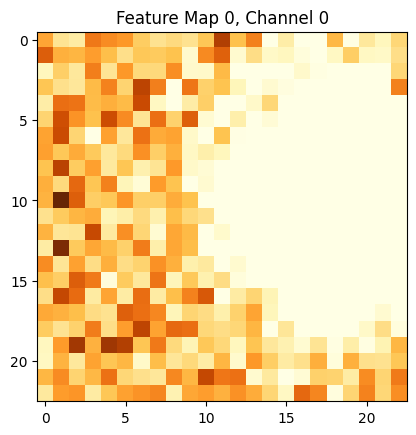

In [107]:
# A single feature map: one channel of the first conv layer's output for this
# one image.
plt.imshow(feature_maps[0][0, 0, :, :].detach().cpu(), cmap='YlOrBr')

plt.title('Feature Map 0, Channel 0');

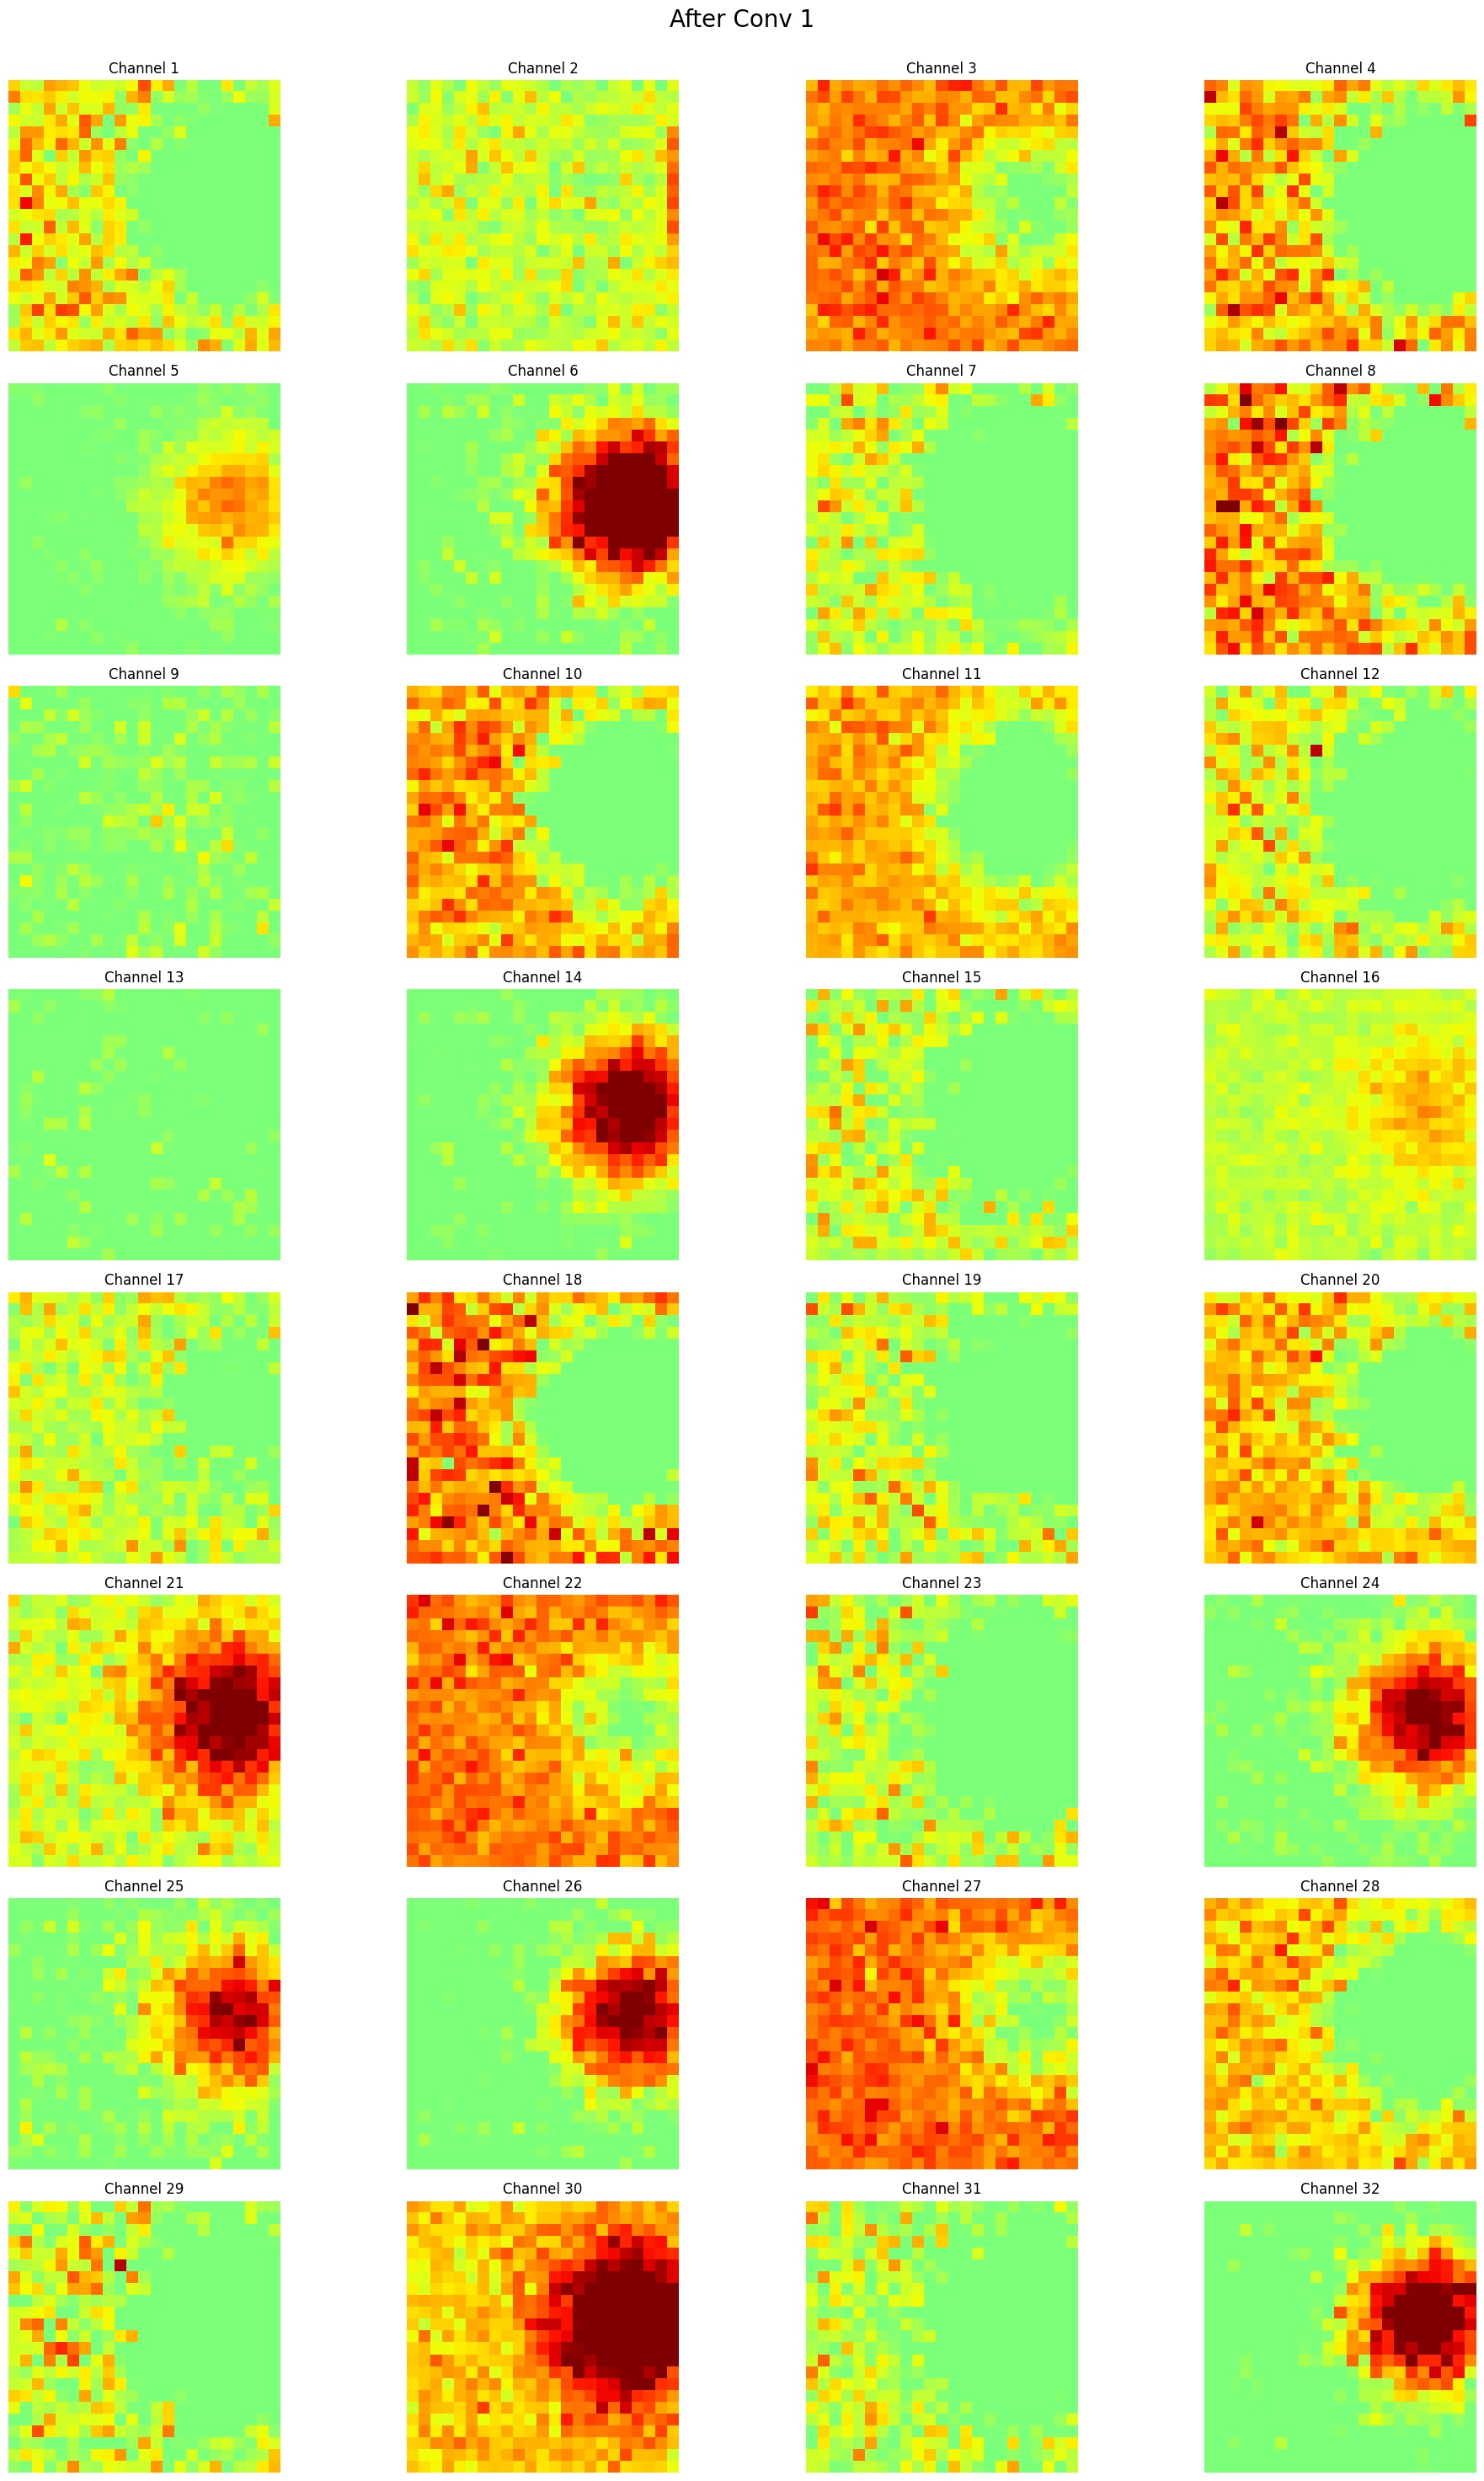

In [114]:
# All 32 channels after conv1. Each is the input filtered by a different learned
# kernel - some highlight edges, some invert contrast, some respond to the blob's
# interior. Compare with the hand-designed edge detectors in
# Convolution and transformations/Convolutions_in_Code.ipynb: the network
# rediscovered that family of filters on its own.
fig, ax = plt.subplots(8,4, figsize=(20, 30))

ax = ax.flatten()

fig.suptitle('After Conv 1\n\n', fontsize=20)


for i in range(32):
  ax[i].imshow(feature_maps[0][0, i, :, :].detach().cpu(), vmin=-1, vmax=1, cmap='jet')
  ax[i].set_title(f'Channel {i+1}')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

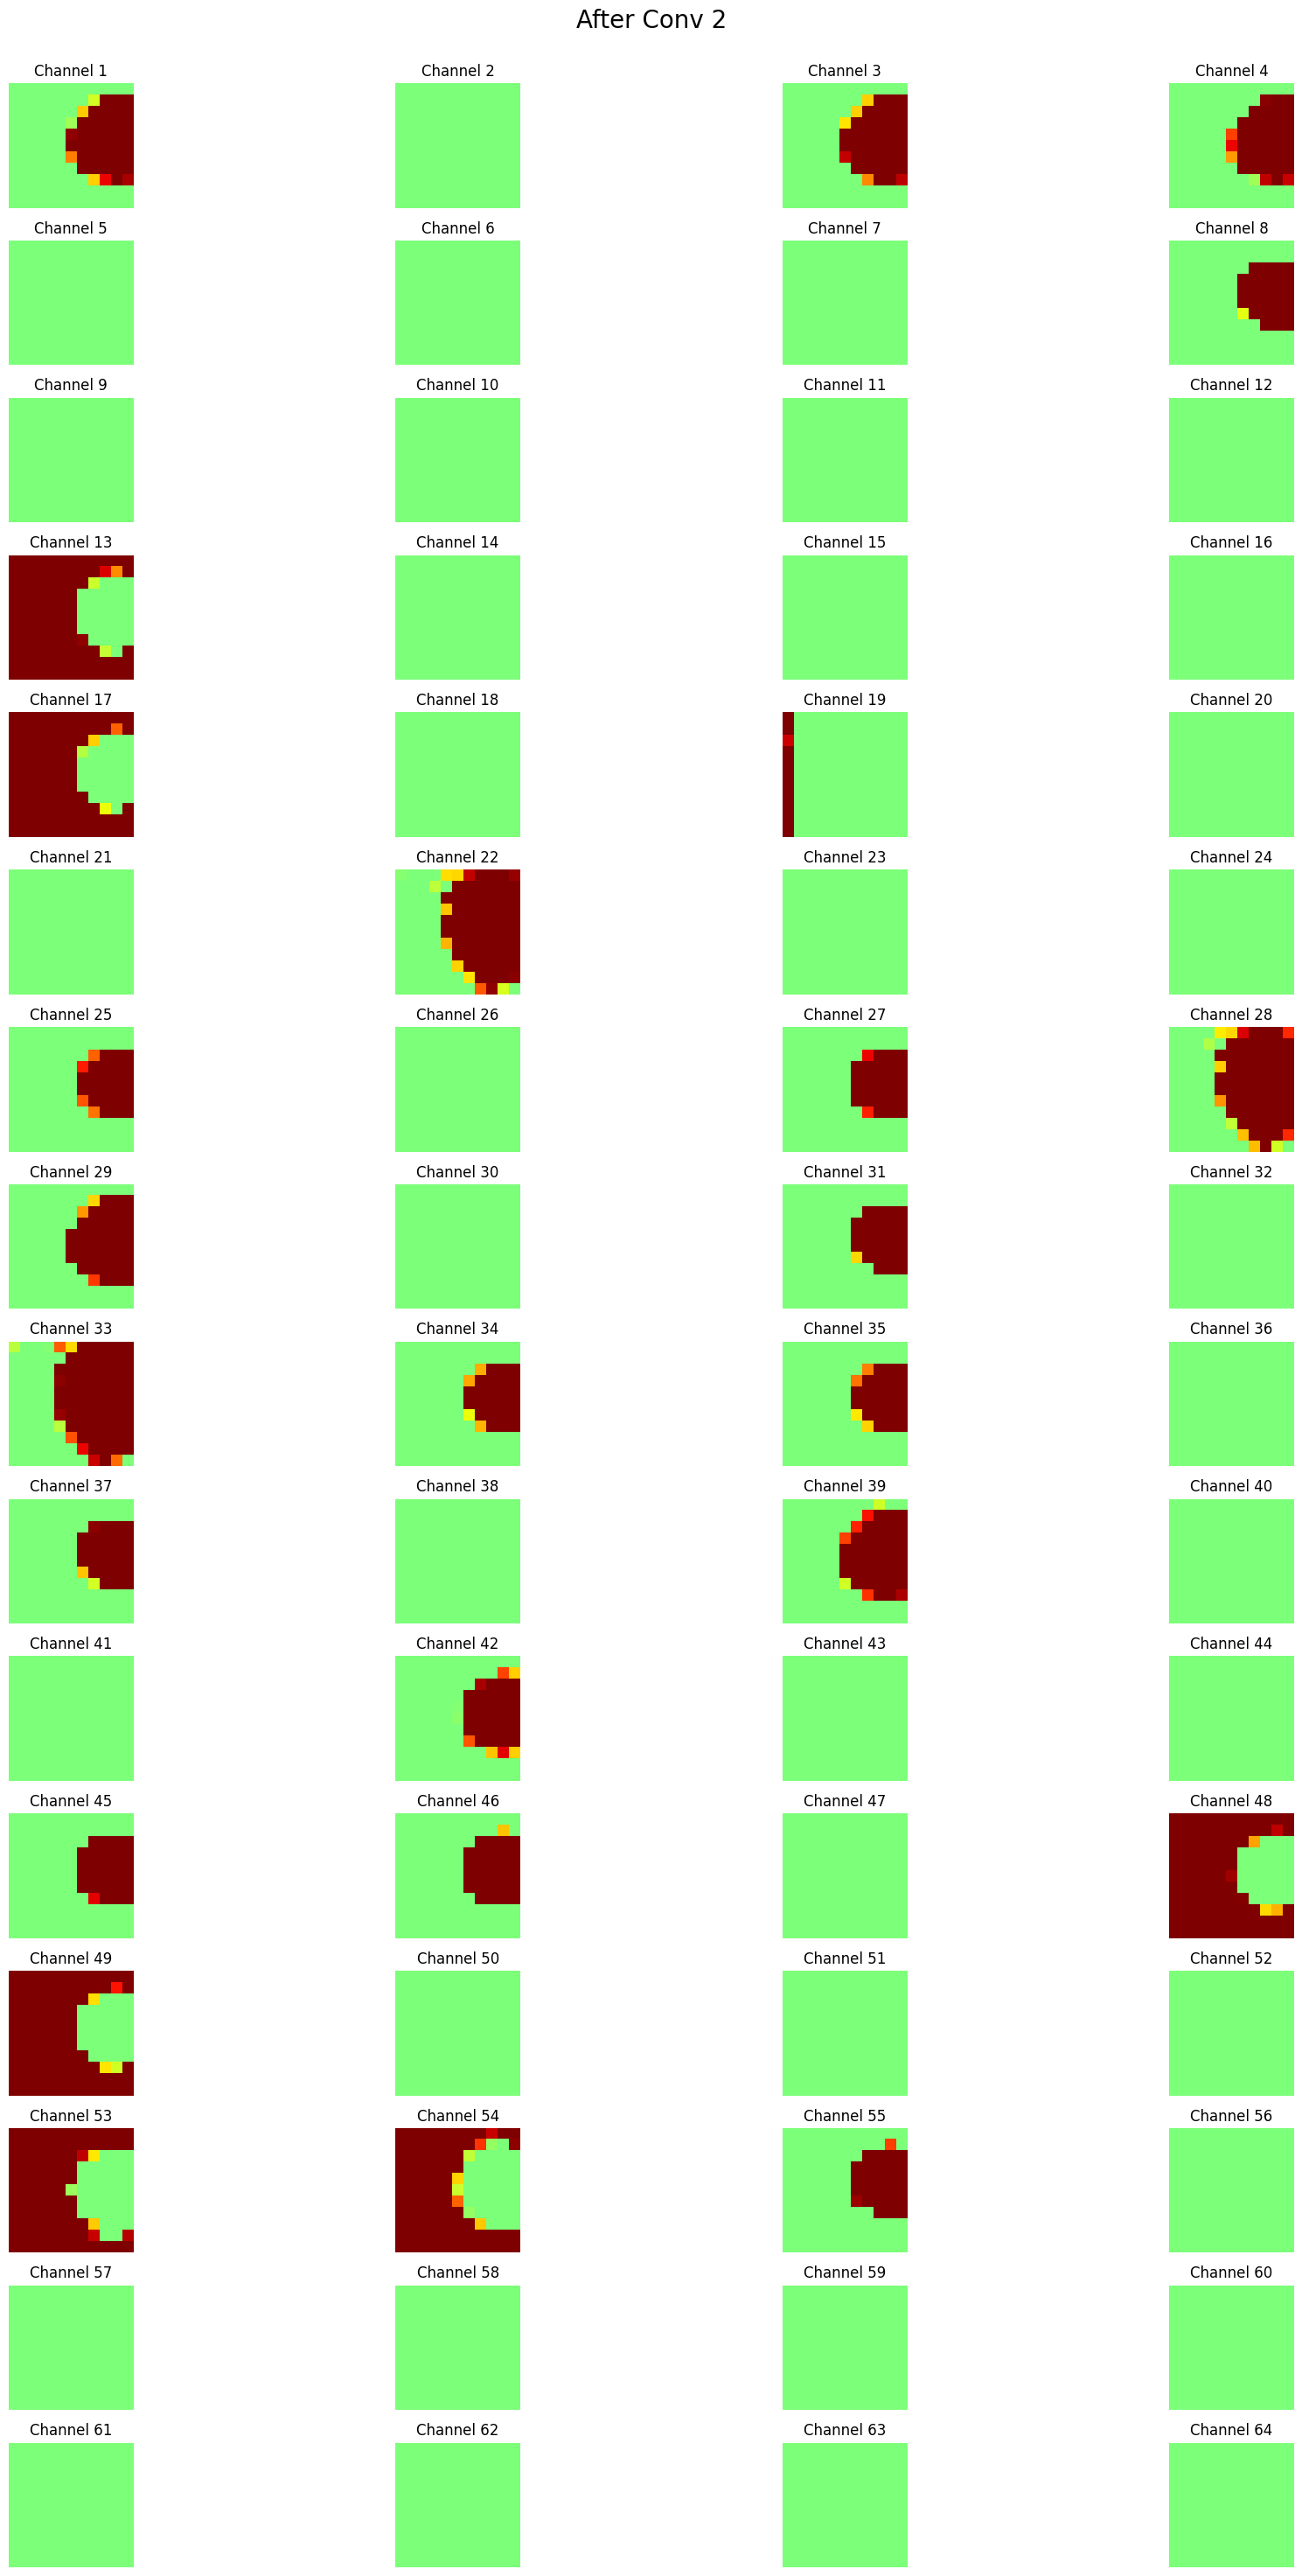

In [119]:
# After conv2: 64 channels, half the spatial size, visibly more abstract.
num_channels = feature_maps[1].shape[1]
fig, ax = plt.subplots(int(np.ceil(num_channels/4)), 4, figsize=(20, 30))
ax = ax.flatten()

fig.suptitle('After Conv 2\n\n', fontsize=20)

for i in range(num_channels):
  ax[i].imshow(feature_maps[1][0, i, :, :].detach().cpu(), vmin=-1, vmax=1, cmap='jet')
  ax[i].set_title(f'Channel {i+1}')
  ax[i].axis('off')

# Hide unused subplots
for j in range(i + 1, len(ax)):
  ax[j].axis('off')

plt.tight_layout()
plt.show()

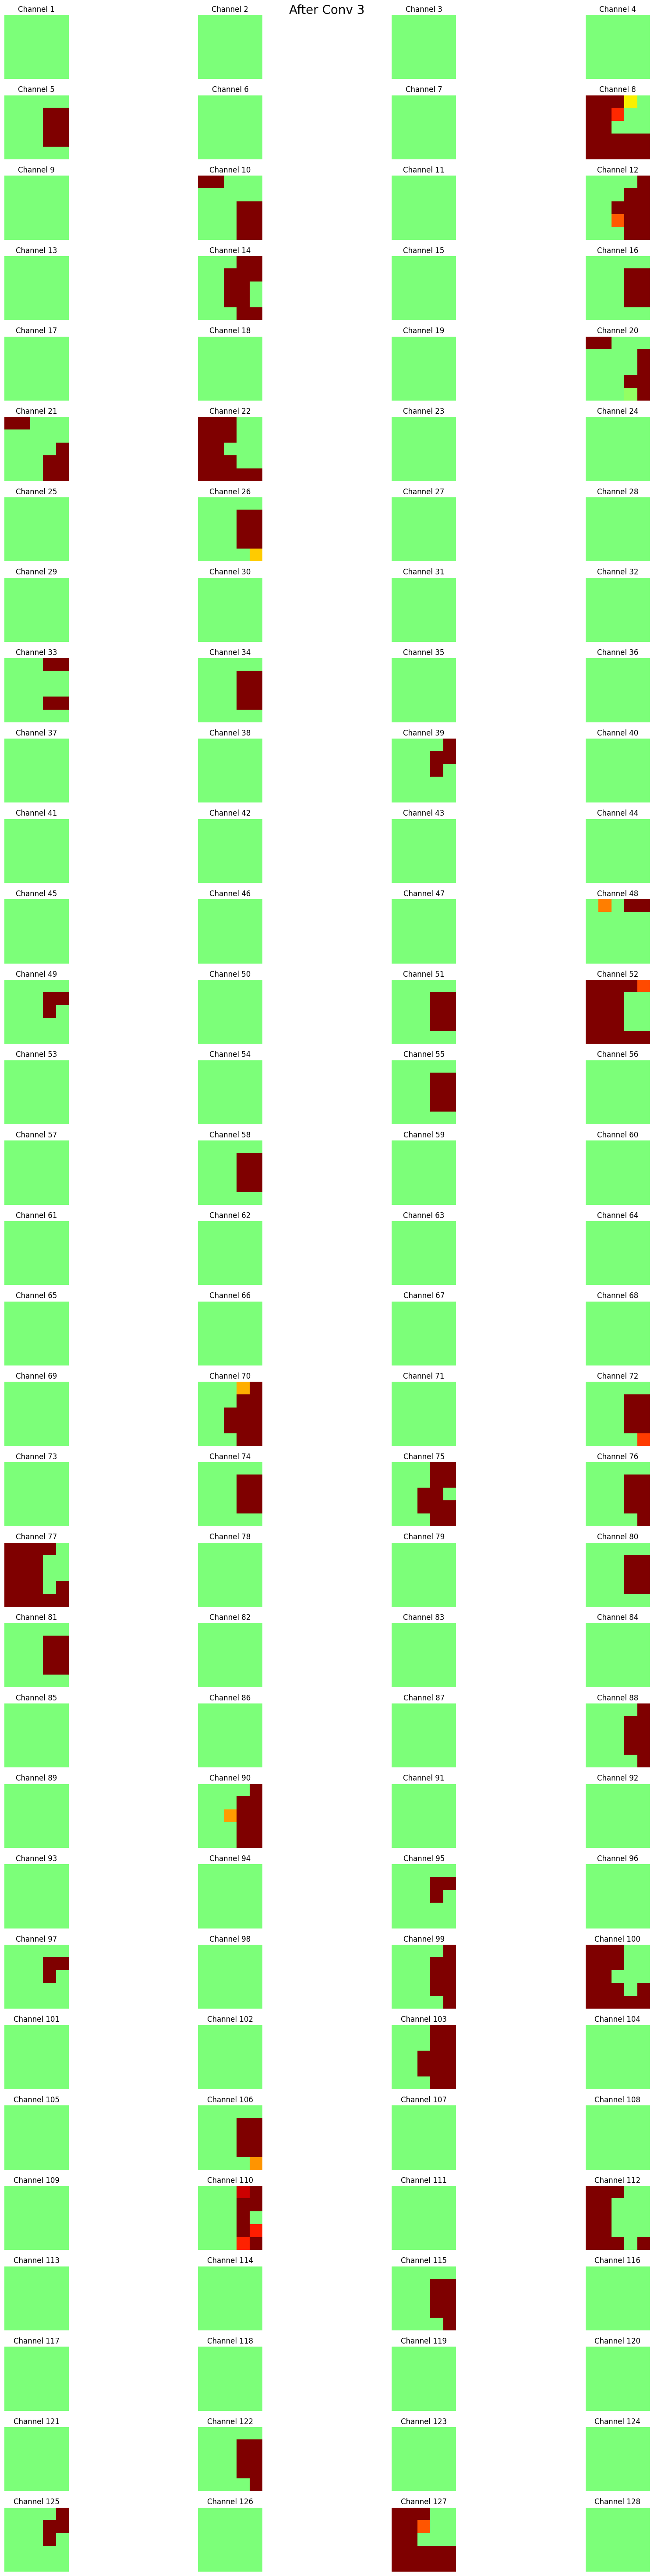

In [120]:
# After conv3: 128 channels, small and no longer interpretable by eye. These are
# the features the classifier actually consumes.
num_channels = feature_maps[2].shape[1]
fig, ax = plt.subplots(int(np.ceil(num_channels/4)), 4, figsize=(20, 60))
ax = ax.flatten()

fig.suptitle('After Conv 3\n\n', fontsize=20)

for i in range(num_channels):
  ax[i].imshow(feature_maps[2][0, i, :, :].detach().cpu(), vmin=-1, vmax=1, cmap='jet')
  ax[i].set_title(f'Channel {i+1}')
  ax[i].axis('off')

for j in range(i + 1, len(ax)):
  ax[j].axis('off')

plt.tight_layout()
plt.show()

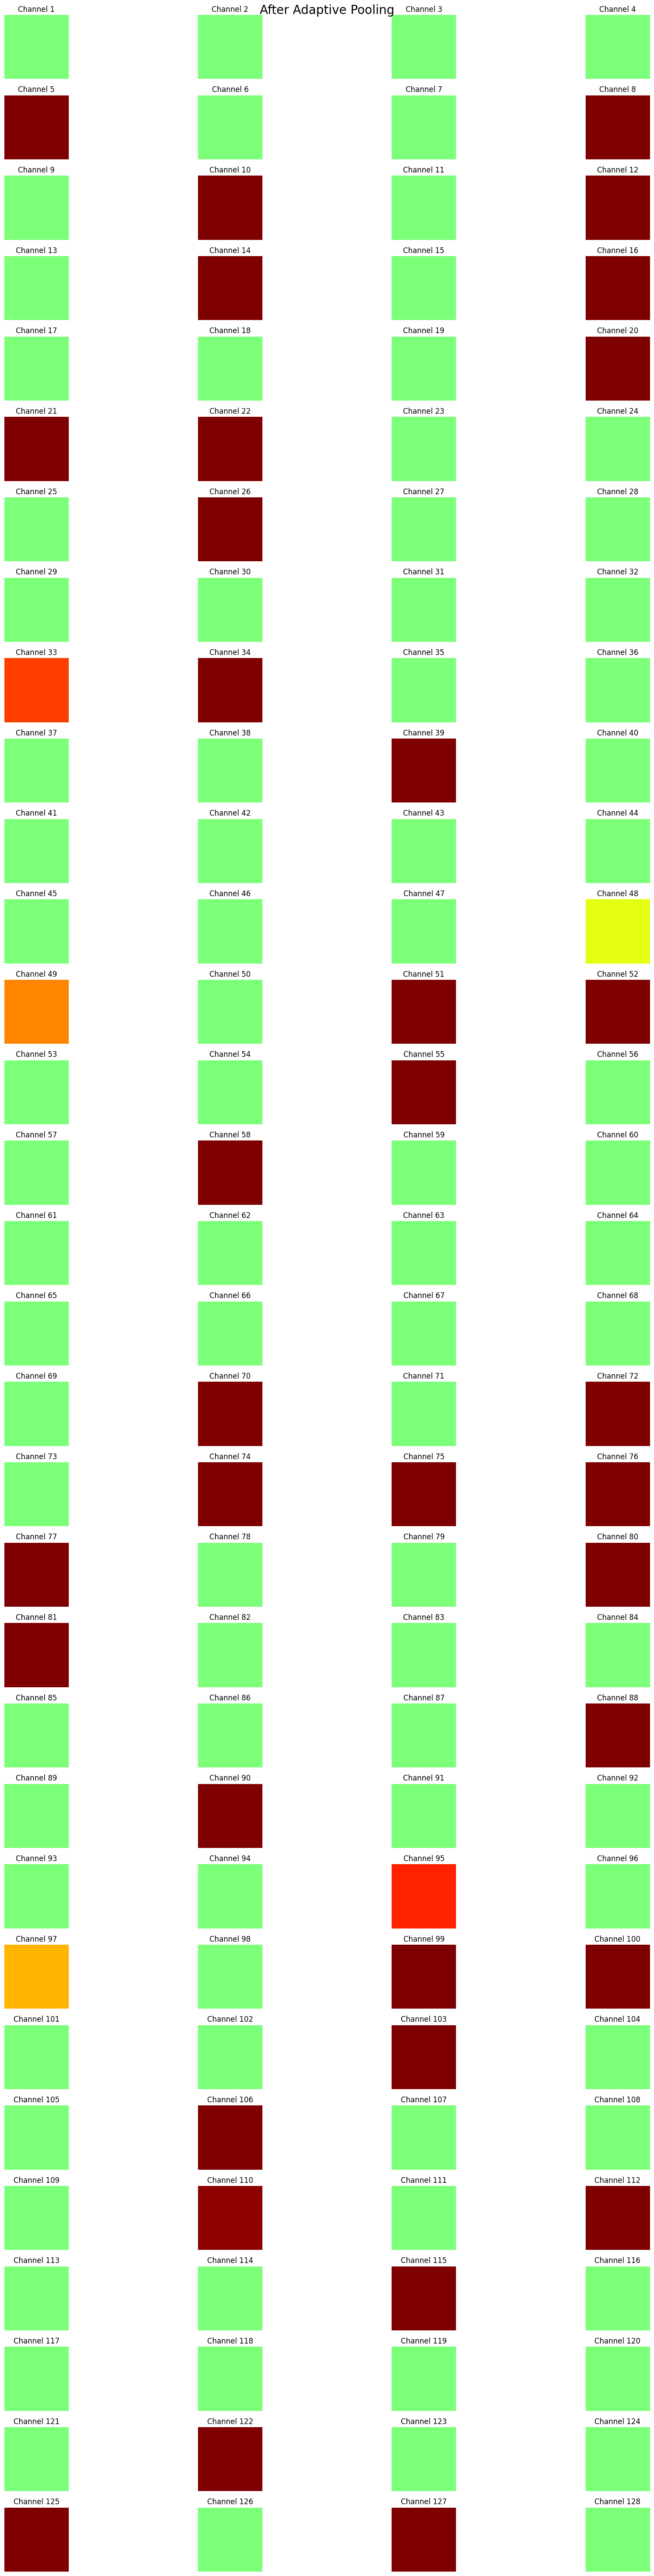

In [121]:
# After global average pooling: each channel is one number, so each panel is a
# single pixel. This is the 128-vector the fully connected head sees - the
# network's entire description of the image.
num_channels = feature_maps[3].shape[1]
fig, ax = plt.subplots(int(np.ceil(num_channels/4)), 4, figsize=(20, 60))
ax = ax.flatten()

fig.suptitle('After Adaptive Pooling\n\n', fontsize=20)

for i in range(num_channels):
  ax[i].imshow(feature_maps[3][0, i, :, :].detach().cpu(), vmin=-1, vmax=1, cmap='jet')
  ax[i].set_title(f'Channel {i+1}')
  ax[i].axis('off')

for j in range(i + 1, len(ax)):
  ax[j].axis('off')

plt.tight_layout()
plt.show()